In [1]:
import sys
from pathlib import Path
from pyprojroot import here

sys.path.append(str(here()))


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from src.config import cfg

In [4]:
from src.my_utils import set_seed

In [5]:
gseed = cfg.general.seed
set_seed(gseed)

In [6]:
train_path = Path(cfg.paths.train)
test_path = Path(cfg.paths.test)

In [7]:
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)


### First look

In [8]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [10]:
print(df_train.columns, end="\n\n")
print(df_test.columns, end="\n\n")
print("Columns diff:", set(df_train.columns) - set(df_test.columns))


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Columns diff: {'Survived'}


In [11]:
# sizes
print("train shape: ", df_train.shape)
print("test shape: ", df_test.shape)


train shape:  (891, 12)
test shape:  (418, 11)


In [12]:
df_train.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [13]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [14]:
df_train["Pclass"] = df_train["Pclass"].astype(str)
df_test["Pclass"] = df_test["Pclass"].astype(str)

In [15]:
# числовые признаки, часть из них на самом деле категориальные
df_train.describe(include=["int64", "float64"])


,PassengerId,Survived,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
df_test.describe(include=["int64", "float64"])

,PassengerId,Age,SibSp,Parch,Fare
count,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,30.272590,0.447368,0.392344,35.627188
std,120.810458,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,76.000000,8.000000,9.000000,512.329200


In [17]:
# категориальные признаки
df_train.describe(include=["str"])


,Pclass,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,204,889
unique,3,891,2,681,147,3
top,3,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,491,1,577,7,4,644


In [18]:
df_test.describe(include=["str"])


,Pclass,Name,Sex,Ticket,Cabin,Embarked
count,418,418,418,418,91,418
unique,3,418,2,363,76,3
top,3,"Kelly, Mr. James",male,PC 17608,B57 B59 B63 B66,S
freq,218,1,266,5,3,270


In [19]:
# [
#     "PassengerId",  # ! отбросить
#     "Survived",  # * целевая переменная (bool)
#     "Pclass",  # класс билета (cat)
#     "Name",  # ? фио (и титулы), ПО СУТИ БОЛЬШАЯ СТРОКА
#     "Sex",  # пол (cat)
#     "Age",  # ? пока num, но может cat
#     "SibSp",  # братья, сестры, сводные или супруги (num)
#     "Parch",  # родители или дети (num)
#     "Ticket",  # ? билет и какие-то символы, ТОЖЕ БОЛЬШАЯ СТРОКА
#     "Fare",  # стоимость билета (num)
#     "Cabin",  # ? номер каюты (cat или num)
#     "Embarked",  # порт (cat)
# ]

Кажется нужно присмотреться к Name и Ticket

In [20]:
print(df_train["Name"].nunique())
print(df_train["Ticket"].nunique())  # не все уникальные

891
681


In [21]:
df_train["Ticket"].value_counts()

Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
370376             1
Name: count, Length: 681, dtype: int64

In [22]:
df_train[df_train["Ticket"] == "347082"]  # семья

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.275,NaN,S
119,120,0,3,"Andersson, Miss. Ellis Anna Maria",female,2.0,4,2,347082,31.275,NaN,S
541,542,0,3,"Andersson, Miss. Ingeborg Constanzia",female,9.0,4,2,347082,31.275,NaN,S
542,543,0,3,"Andersson, Miss. Sigrid Elisabeth",female,11.0,4,2,347082,31.275,NaN,S
610,611,0,3,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",female,39.0,1,5,347082,31.275,NaN,S
813,814,0,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.275,NaN,S
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.275,NaN,S


In [23]:
df_train[df_train["Ticket"] == "1601"]  # знакомые?

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
74,75,1,3,"Bing, Mr. Lee",male,32.0,0,0,1601,56.4958,NaN,S
169,170,0,3,"Ling, Mr. Lee",male,28.0,0,0,1601,56.4958,NaN,S
509,510,1,3,"Lang, Mr. Fang",male,26.0,0,0,1601,56.4958,NaN,S
643,644,1,3,"Foo, Mr. Choong",male,NaN,0,0,1601,56.4958,NaN,S
692,693,1,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S
826,827,0,3,"Lam, Mr. Len",male,NaN,0,0,1601,56.4958,NaN,S
838,839,1,3,"Chip, Mr. Chang",male,32.0,0,0,1601,56.4958,NaN,S


### Итог:
* Визуально датасеты не сильно различаются, имеют примерно схожие статистики
* С одним билетом могут быть члены семьи (есть SibSp или Parch) или знакомые (нет SibSp или Parch)
* Полное число человек в семье = SibSp + Parch + 1

### Duplicates

In [24]:
print(df_train.duplicated().mean())  # дублей нет
print(df_test.duplicated().mean())  # дублей нет

0.0
0.0


In [25]:
cat_columns = df_train.select_dtypes(include=[str, object]).columns.tolist()
print("cat:", cat_columns)
num_columns = df_train.select_dtypes(exclude=[str, object]).columns.tolist()
print("num:", num_columns)

cat: ['Pclass', 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
num: ['PassengerId', 'Survived', 'Age', 'SibSp', 'Parch', 'Fare']


### Unique

In [26]:
for col in df_train.columns:
    print(f"col: {col}, nunique: {df_train[col].nunique()}")

col: PassengerId, nunique: 891
col: Survived, nunique: 2
col: Pclass, nunique: 3
col: Name, nunique: 891
col: Sex, nunique: 2
col: Age, nunique: 88
col: SibSp, nunique: 7
col: Parch, nunique: 7
col: Ticket, nunique: 681
col: Fare, nunique: 248
col: Cabin, nunique: 147
col: Embarked, nunique: 3


In [27]:
for col in df_test.columns:
    print(f"col: {col}, nunique: {df_test[col].nunique()}")

col: PassengerId, nunique: 418
col: Pclass, nunique: 3
col: Name, nunique: 418
col: Sex, nunique: 2
col: Age, nunique: 79
col: SibSp, nunique: 7
col: Parch, nunique: 8
col: Ticket, nunique: 363
col: Fare, nunique: 169
col: Cabin, nunique: 76
col: Embarked, nunique: 3


### corr

<Axes: >

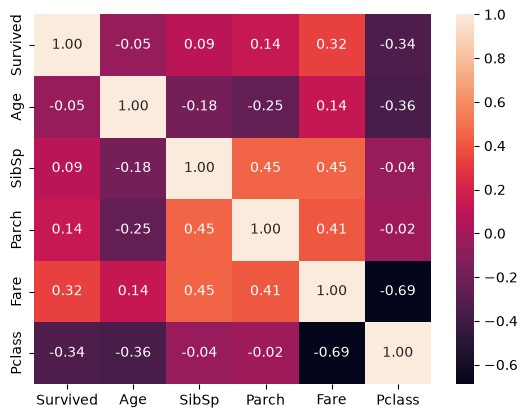

In [28]:
sns.heatmap(
    df_train[num_columns + ["Pclass"]]
    .drop(columns=["PassengerId"])
    .astype(float)
    .corr(method="spearman"),  # ранги более уместны
    annot=True,
    fmt=".2f",
)

# корелляция Pclass и Fare довольно очевидна
#

### Nan

In [29]:
temp = df_train.isna().mean().sort_values(ascending=False)
temp[temp > 0]
# Cabin - много пропусков
# Age
# Embarked

Cabin       0.771044
Age         0.198653
Embarked    0.002245
dtype: float64

In [30]:
temp = df_test.isna().mean().sort_values(ascending=False)
temp[temp > 0]
# Cabin
# Age
# Fare - другой пропуск

Cabin    0.782297
Age      0.205742
Fare     0.002392
dtype: float64

### Target

In [31]:
def simple_countplot(
    data: pd.DataFrame, x: str, hue: str = "Survived", palette: str = "Set2"
):
    fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
    g = sns.countplot(data=data, x=x, hue=hue, palette=palette)
    g.set(xlabel=x, ylabel="Count", title=f"{x} effect on {hue}")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

    plt.show()

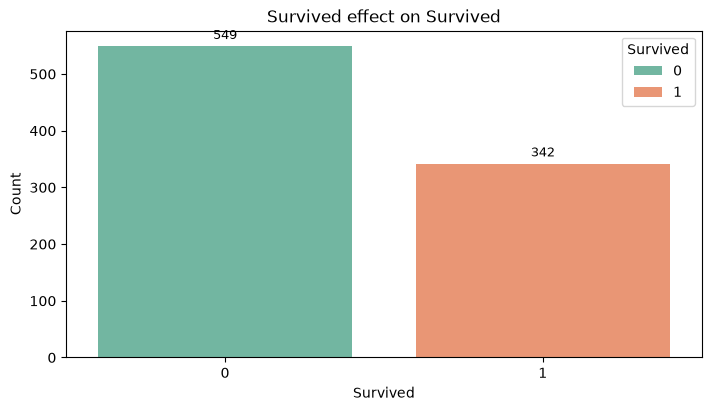

In [32]:
simple_countplot(df_train, "Survived", hue="Survived", palette="Set2")

In [33]:
df_train["Survived"].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

### Features

Pclass

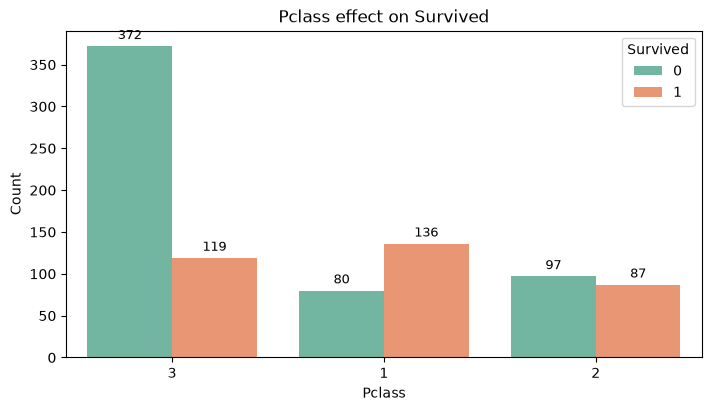

In [34]:
simple_countplot(df_train, "Pclass")
# и в абсолютных и в относительных значениях первый класс много спасался

Sex

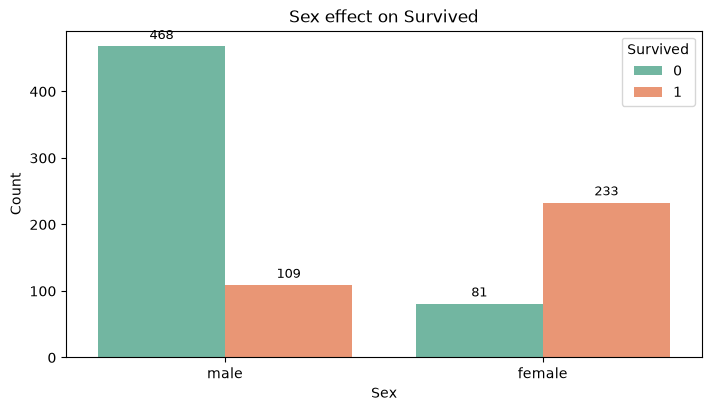

In [35]:
simple_countplot(df_train, "Sex")
# женщин меньше, а спаслось больше

Age

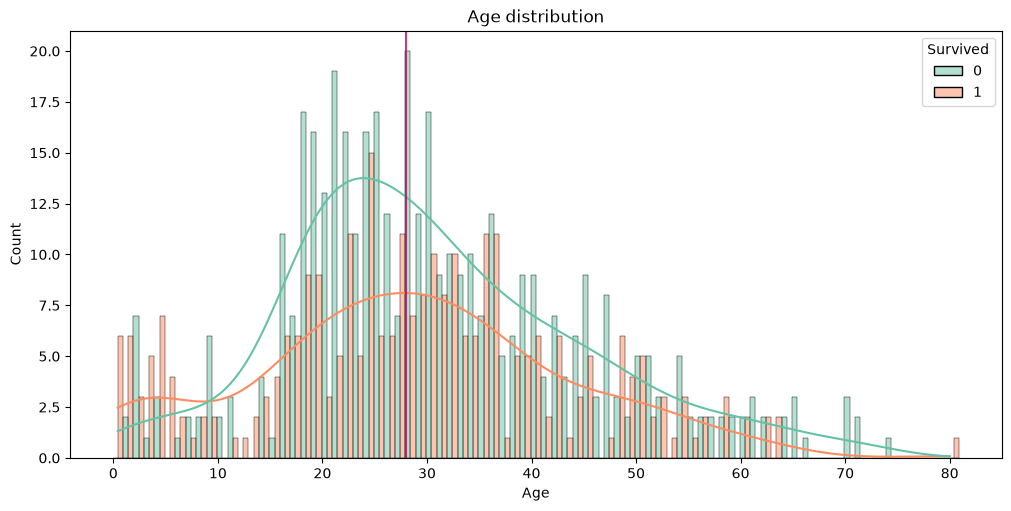

In [36]:
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
g = sns.histplot(
    data=df_train,
    x="Age",
    hue="Survived",
    palette="Set2",
    kde=True,
    discrete=True,
    multiple="dodge",
    ax=ax,
)
g.set(xlabel="Age", title="Age distribution")


median_0 = df_train[df_train["Survived"] == 0]["Age"].median()
median_1 = df_train[df_train["Survived"] == 1]["Age"].median()

ax.axvline(median_0, color="blue", alpha=0.5)
ax.axvline(median_1, color="red", alpha=0.5)

# возрастные медианы совпадают, получается в среднем возраст не сильно влияет
# но детей (до 10) чаще спасали

SibSp

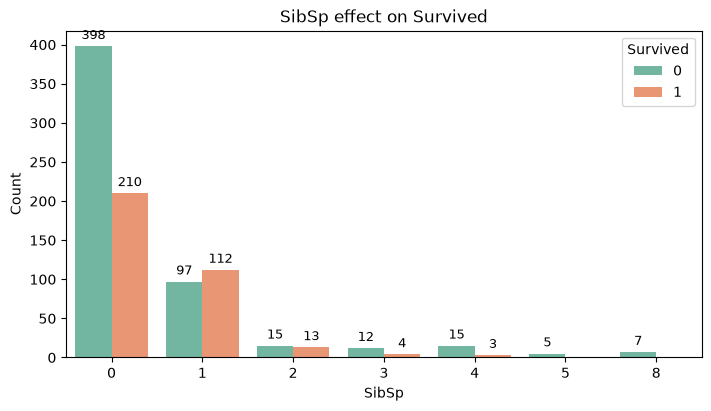

In [37]:
simple_countplot(
    df_train, "SibSp"
)  # пока пусть будте num, можно попробовать cat (бины)

Parch

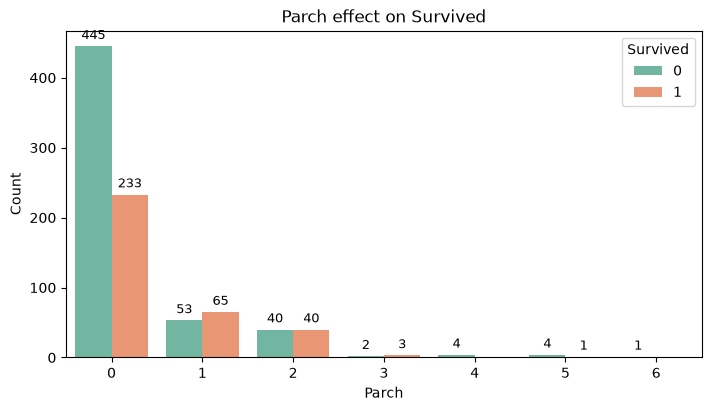

In [38]:
simple_countplot(
    df_train, "Parch"
)  # пока пусть будте num, можно попробовать cat (бины)

Fare

In [39]:
df_train["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [40]:
df_train.groupby(by=["Sex", "Pclass"])["Fare"].agg(['mean', 'median'])

mean    median
Sex    Pclass                      
female 1       106.125798  82.66455
       2        21.970121  22.00000
       3        16.118810  12.47500
male   1        67.226127  41.26250
       2        19.741782  13.00000
       3        12.661633   7.92500

In [41]:
df_test.groupby(by=["Sex", "Pclass"])["Fare"].agg(['mean', 'median'])

mean    median
Sex    Pclass                      
female 1       115.591168  79.02500
       2        26.438750  26.00000
       3        13.735129   8.08125
male   1        75.586551  51.86250
       2        20.184654  13.00000
       3        11.826350   7.89580

[Text(0.5, 0, 'Fare'), Text(0.5, 1.0, 'Fare distribution')]

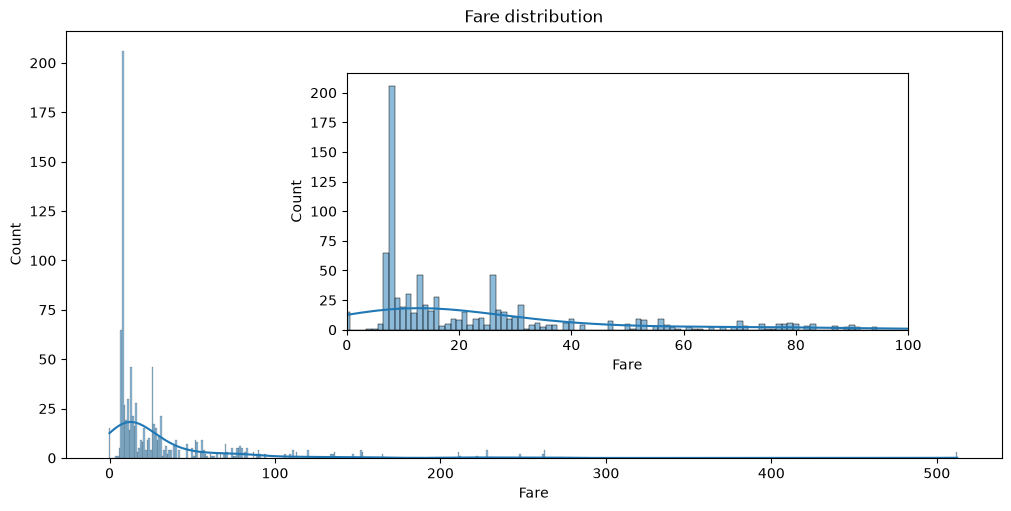

In [42]:
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
g = sns.histplot(
    data=df_train,
    x="Fare",
    kde=True,
    discrete=True,
    multiple="dodge",
    ax=ax,
)
ax_inset = ax.inset_axes([0.3, 0.3, 0.6, 0.6])
ax_inset.set_xlim(0, 100)
g1 = sns.histplot(
    data=df_train,
    x="Fare",
    kde=True,
    discrete=True,
    multiple="dodge",
    ax=ax_inset,
)

g.set(xlabel="Fare", title="Fare distribution")


In [43]:
# Есть нули, а также хвосты у распределения
print(f"Где расположена основная масса данных: {(df_train['Fare'] < 100).mean():.4f}")
print(f"Непонятные нули {(df_train['Fare'] == 0).mean():.4f}")

Где расположена основная масса данных: 0.9405
Непонятные нули 0.0168


cabin

In [44]:
df_train.shape

(891, 12)

In [45]:
print("Уникальных", df_train["Cabin"].nunique())
print("Не нулевые", df_train["Cabin"].count())

Уникальных 147
Не нулевые 204


In [46]:
df_train["Cabin"].value_counts()[:10]

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
F2             3
D              3
C22 C26        3
C123           2
D33            2
Name: count, dtype: int64

In [47]:
df_train[df_train["Cabin"] == "G6"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
205,206,0,3,"Strom, Miss. Telma Matilda",female,2.0,0,1,347054,10.4625,G6,S
251,252,0,3,"Strom, Mrs. Wilhelm (Elna Matilda Persson)",female,29.0,1,1,347054,10.4625,G6,S
394,395,1,3,"Sandstrom, Mrs. Hjalmar (Agnes Charlotta Bengt...",female,24.0,0,2,PP 9549,16.7000,G6,S


* Далеко не у всех есть каюты, но у кого то их даже несколько
* Сильным будет восстановить каюты и хотя бы прикинуть порядок расстояния до спасательных шлюпок

ticket

In [48]:
df_train["ticket_letters"] = (
    df_train["Ticket"].str.split().str[0]
)  # есть как числовые, так с обозначениями

(
    df_train.loc[
        pd.to_numeric(df_train["ticket_letters"], errors="coerce").isna(),
        "ticket_letters",
    ]
).value_counts()
# исторически обозначения дублируют некоторые колонки, но могут обозначать туркомпании или спецтарифы

ticket_letters
PC            60
C.A.          27
STON/O        12
A/5           10
W./C.          9
SOTON/O.Q.     8
CA.            8
A/5.           7
SOTON/OQ       7
STON/O2.       6
CA             6
S.O.C.         5
C              5
SC/PARIS       5
F.C.C.         5
SC/Paris       4
LINE           4
PP             3
A/4.           3
SC/AH          3
A/4            3
S.O./P.P.      3
A./5.          2
A.5.           2
P/PP           2
WE/P           2
SOTON/O2       2
S.C./PARIS     2
S.C./A.4.      1
S.P.           1
SO/C           1
W.E.P.         1
A4.            1
S.O.P.         1
Fa             1
W/C            1
SW/PP          1
SCO/W          1
SC             1
A/S            1
S.W./PP        1
F.C.           1
C.A./SOTON     1
Name: count, dtype: int64

In [49]:
df_train[df_train["ticket_letters"] == "A/5"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,ticket_letters
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,A/5
204,205,1,3,"Cohen, Mr. Gurshon ""Gus""",male,18.0,0,0,A/5 3540,8.05,NaN,S,A/5
212,213,0,3,"Perkin, Mr. John Henry",male,22.0,0,0,A/5 21174,7.25,NaN,S,A/5
227,228,0,3,"Lovell, Mr. John Hall (""Henry"")",male,20.5,0,0,A/5 21173,7.25,NaN,S,A/5
304,305,0,3,"Williams, Mr. Howard Hugh ""Harry""",male,NaN,0,0,A/5 2466,8.05,NaN,S,A/5
320,321,0,3,"Dennis, Mr. Samuel",male,22.0,0,0,A/5 21172,7.25,NaN,S,A/5
454,455,0,3,"Peduzzi, Mr. Joseph",male,NaN,0,0,A/5 2817,8.05,NaN,S,A/5
482,483,0,3,"Rouse, Mr. Richard Henry",male,50.0,0,0,A/5 3594,8.05,NaN,S,A/5
592,593,0,3,"Elsbury, Mr. William James",male,47.0,0,0,A/5 3902,7.25,NaN,S,A/5
668,669,0,3,"Cook, Mr. Jacob",male,43.0,0,0,A/5 3536,8.05,NaN,S,A/5


Embarked

In [50]:
df_train[df_train["Embarked"].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,ticket_letters
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,113572
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,113572


In [51]:
df_train[df_train["Ticket"] == "113572"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,ticket_letters
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,113572
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,113572


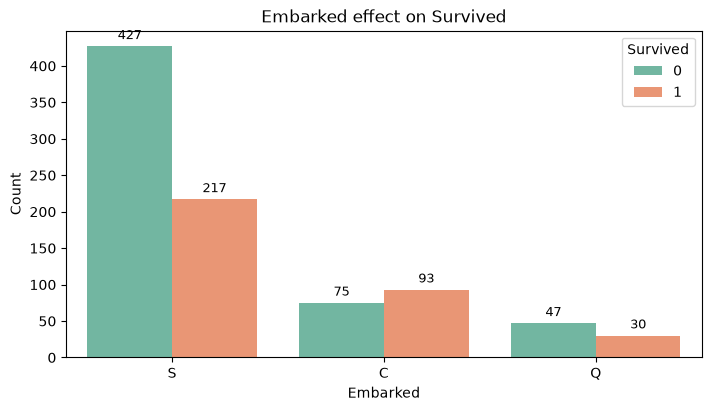

In [52]:
simple_countplot(df_train, "Embarked")

# Advanced

Есть предположение, что женщин было больше в первом классе

In [53]:
# Женщин не было больше в 1 классе, процент выживаемости в целом высокий
df_train.groupby(by=["Pclass", "Sex"])["Survived"].agg(["count", "mean"])

count      mean
Pclass Sex                    
1      female     94  0.968085
       male      122  0.368852
2      female     76  0.921053
       male      108  0.157407
3      female    144  0.500000
       male      347  0.135447

Возрастная медиана для групп

In [54]:
# есть тенденция - чем ниже класс билета, тем ниже возраст
df_train.groupby(by=["Pclass", "Sex"])["Age"].agg(["median", "mean"])

median       mean
Pclass Sex                      
1      female    35.0  34.611765
       male      40.0  41.281386
2      female    28.0  28.722973
       male      30.0  30.740707
3      female    21.5  21.750000
       male      25.0  26.507589

In [55]:
# возрастное распределение в test немного отличатеся
df_test.groupby(by=["Pclass", "Sex"])["Age"].agg(["median", "mean"])

median       mean
Pclass Sex                      
1      female    41.0  41.333333
       male      42.0  40.520000
2      female    24.0  24.376552
       male      28.0  30.940678
3      female    22.0  23.073400
       male      24.0  24.525104

Нули в Fare

In [56]:
# какая то особая группа людей, лучше будет заменить нули на медиану
df_train[df_train["Fare"] == 0].sort_values(by=["Pclass"])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,ticket_letters
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S,112059
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0,NaN,S,112052
806,807,0,1,"Andrews, Mr. Thomas Jr",male,39.0,0,0,112050,0.0,A36,S,112050
815,816,0,1,"Fry, Mr. Richard",male,NaN,0,0,112058,0.0,B102,S,112058
822,823,0,1,"Reuchlin, Jonkheer. John George",male,38.0,0,0,19972,0.0,NaN,S,19972
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S,239853
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,NaN,S,239853
466,467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,NaN,S,239853
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,NaN,S,239854
674,675,0,2,"Watson, Mr. Ennis Hastings",male,NaN,0,0,239856,0.0,NaN,S,239856


Максимальный fare

In [57]:
df_train[
    df_train["Fare"] >= 250
]  # fare имеет корреляцию с sibsp и parch, значит цена билета зависит от количества людей

# нужно сагрегирвать число людей по билету, но возможно утверждение справедливо не для всех категорий

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,ticket_letters
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,19950
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S,19950
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,PC
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C,PC
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S,19950
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S,19950
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,PC
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,PC
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C,PC


fare в test

In [58]:
df_test[df_test["Fare"] == 0]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
266,1158,1,"Chisholm, Mr. Roderick Robert Crispin",male,NaN,0,0,112051,0.0,NaN,S
372,1264,1,"Ismay, Mr. Joseph Bruce",male,49.0,0,0,112058,0.0,B52 B54 B56,S


Фамилия

In [59]:
df_train["lastname"] = df_train["Name"].str.split(r"[,\s]+", regex=True).str[0]

In [60]:
df_train["lastname"].value_counts()  # 661 уникальная фамилия

lastname
Andersson    9
Sage         7
Johnson      6
Panula       6
Goodwin      6
            ..
Banfield     1
Sutehall     1
Montvila     1
Behr         1
Dooley       1
Name: count, Length: 661, dtype: int64

In [61]:
temp = df_test["Name"].str.split(r"[,\s]+", regex=True).str[0].value_counts()
temp

Name
Davies        4
Thomas        4
Asplund       4
Sage          4
Ware          4
             ..
Henriksson    1
Spector       1
Oliva         1
Saether       1
Peter         1
Name: count, Length: 349, dtype: int64

In [62]:
len(set(temp.index) & set(df_train["lastname"].values))
# много пересекающихся фамилий в train и test

144

In [63]:
df_train["Group"] = df_train["Name"].str.split(",").str[0] + df_train[
    "Ticket"
].str.split(" ").str.join("")

df_test["Group"] = df_test["Name"].str.split(",").str[0] + df_test["Ticket"].str.split(
    " "
).str.join("")

len(set(df_train["Group"]) & set(df_test["Group"]))
# часть членов семьи есть в train, часть в test

95

Статус

In [64]:
# r'[,\s]+' - грязно но работает
df_train["title"] = df_train["Name"].str.extract(r",\s*([^\s.]+)\s*\.")

In [65]:
df_train["title"].value_counts()  # 16 статусов

title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Jonkheer      1
Name: count, dtype: int64

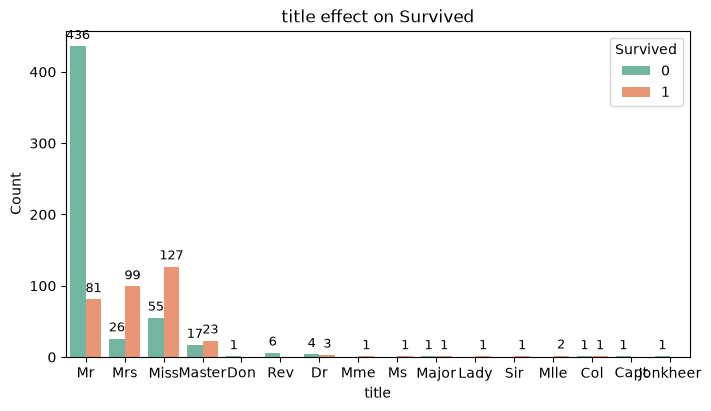

In [66]:
simple_countplot(
    df_train, "title"
)  # много довольно похожих названий для одного и того же, редких объединить

In [77]:
temp = df_test["Name"].str.extract(r",\s*([^\s.]+)\s*\.")[0].value_counts()
temp  # в test меньше титулов

0
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [79]:
set(temp.index) - set(df_train['title'].value_counts().index)

{'Dona'}

Ticket

In [ ]:
df_train.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,ticket_letters,lastname,Group,title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,A/5,Braund,BraundA/521171,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,PC,Cumings,CumingsPC17599,Mrs


In [ ]:
def letters_extractor(x):
    x = x.split()[0]
    if x.isdigit():
        return "Numeric"

    x = x.split()[0]
    x = x.replace(" ", "").replace("/", "").replace(".", "").upper()
    return x

In [ ]:
df_train["ticket_letters"] = df_train["Ticket"].apply(letters_extractor)

In [ ]:
df_train["ticket_letters"].value_counts()[:15]  # может пригодится

ticket_letters
Numeric    661
PC          60
CA          41
A5          21
SOTONOQ     15
STONO       12
SCPARIS     11
WC          10
A4           7
STONO2       6
SOC          6
C            5
FCC          5
LINE         4
PP           3
Name: count, dtype: int64

cabines

In [ ]:
df_train['Deck'] = df_train['Cabin'].dropna().str[0]

deck_pclass = pd.crosstab(df_train['Deck'], df_train['Pclass'])
deck_pclass

Pclass,1,2,3
Deck,,,
A,15,0,0
B,47,0,0
C,59,0,0
D,29,4,0
E,25,4,3
F,0,8,5
G,0,0,4
T,1,0,0


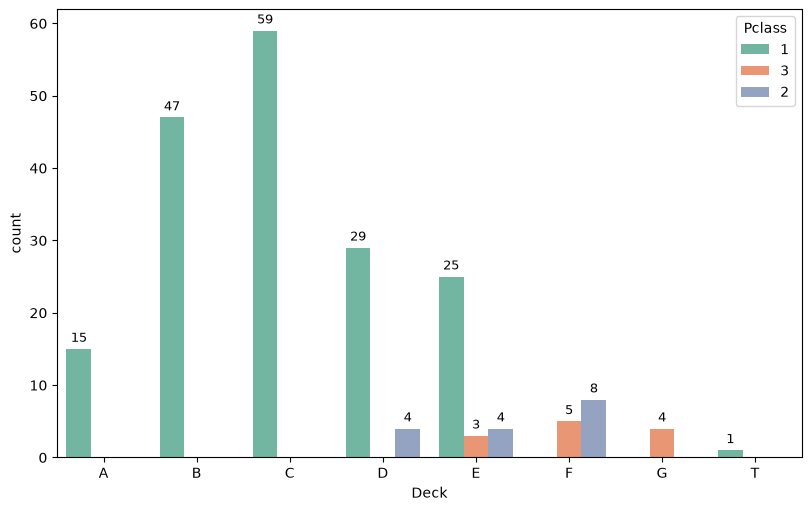

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

sns.countplot(
    data=df_train.dropna(subset=['Deck']), 
    x='Deck', 
    hue='Pclass', 
    palette='Set2', 
    order=sorted(df_train['Deck'].dropna().unique()),
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

In [ ]:
df_test['Deck'] = df_test['Cabin'].dropna().str[0]

deck_pclass = pd.crosstab(df_test['Deck'], df_test['Pclass'])
deck_pclass

Pclass,1,2,3
Deck,,,
A,7,0,0
B,18,0,0
C,35,0,0
D,11,2,0
E,9,0,0
F,0,5,3
G,0,0,1


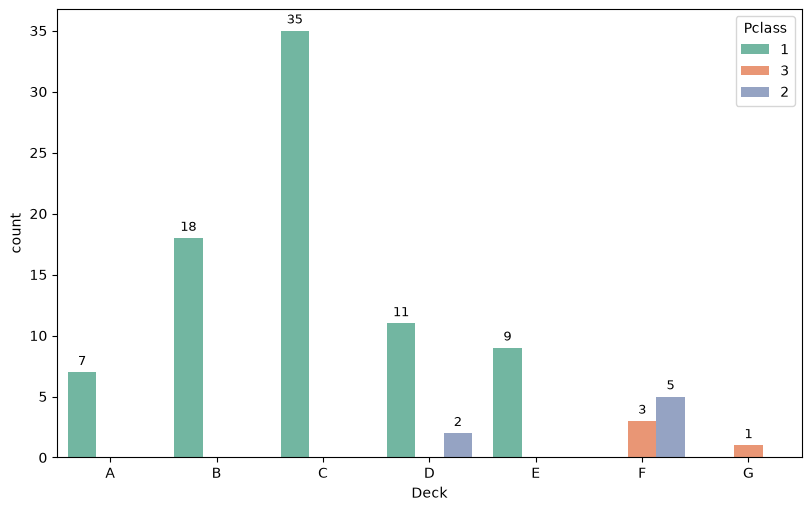

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

sns.countplot(
    data=df_test.dropna(subset=['Deck']), 
    x='Deck', 
    hue='Pclass', 
    palette='Set2', 
    order=sorted(df_test['Deck'].dropna().unique()),
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

In [ ]:
# Информация по каютам довольно скудная, преимущественно - первый класс, где выжило больше. Имеет смысл создать фичу с наличием кабины и encoded фичу с кабинами для известных и unk для остальных

сравнить train и test (Adversarial Validation)

In [ ]:
df_train = pd.read_csv(train_path).drop(columns=["Survived"])
df_test = pd.read_csv(test_path)

In [ ]:
df_train["ds"] = 0
df_test["ds"] = 1

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [ ]:
cat_transformer = Pipeline(
    [
        ("cat_imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),  # норм
    ]
)

num_transformer = Pipeline(
    [("num_imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

In [ ]:
cat_columns = ["Pclass", "Sex", "Embarked"]
num_columns = ["Age", "SibSp", "Parch", "Fare"]

In [ ]:
preprocessor = ColumnTransformer(
    [("cat", cat_transformer, cat_columns), ("num", num_transformer, num_columns)]
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
pipe = Pipeline(
    [
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(random_state=gseed)),
    ]
)

In [ ]:
df_all = pd.concat([df_train, df_test], axis=0, ignore_index=True)

y_all = df_all["ds"]
X_all = df_all.drop(columns=["ds"])

In [ ]:
from sklearn.model_selection import cross_validate

In [ ]:
score = cross_validate(
    pipe, X_all, y_all, scoring="roc_auc", cv=10, return_train_score=True
)

In [ ]:
cv_report = pd.DataFrame(score)
cv_report

,fit_time,score_time,test_score,train_score
0,0.418153,0.035152,0.476558,0.983740
1,0.395749,0.040063,0.465356,0.983996
2,0.453707,0.039815,0.529561,0.984696
3,0.339088,0.026759,0.519395,0.984127
4,0.391288,0.028168,0.573970,0.985175
5,0.371865,0.027714,0.516854,0.985014
6,0.364387,0.033811,0.480070,0.986435
7,0.411993,0.028703,0.533039,0.984366
8,0.331169,0.045366,0.617442,0.982794
9,0.400817,0.023951,0.453823,0.984093


In [ ]:
result = cv_report[["train_score", "test_score"]].agg(["mean", "std"])
result
# датасеты однородны

,train_score,test_score
mean,0.984444,0.516607
std,0.000974,0.051003
